In [227]:
import pandas as pd
import numpy as np
from tqdm.auto import tqdm, trange
import nltk
import re
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

In [228]:
data = pd.read_csv('dump.csv')

In [229]:
data.shape

(83707, 5)

In [230]:
data.head(5)

,Название,Артикул,Категория,Цена без карты,Цена с картой
0,Проходка BORGE Кровельная D6-50мм прямая №1,17162301,"Главная,Каталог,Строительные материалы,Кровля,...",329.33 ₽,312.86 ₽
1,Аэратор ТЕХНОНИКОЛЬ КТВ,17575401,"Главная,Каталог,Строительные материалы,Кровля,...",1 529.00 ₽,1 452.55 ₽
2,Аэратор ТЕХНОНИКОЛЬ Pilot скатный,17575301,"Главная,Каталог,Строительные материалы,Кровля,...",3 008.00 ₽,2 857.60 ₽
3,Проходной элемент ТЕХНОНИКОЛЬ Shinglas,17575701,"Главная,Каталог,Строительные материалы,Кровля,...",1 172.00 ₽,1 113.40 ₽
4,Вентиль ТЕХНОНИКОЛЬ Skat кровельный,17575501,"Главная,Каталог,Строительные материалы,Кровля,...",2 396.00 ₽,2 276.20 ₽


In [231]:
topics = [
          'Главная,Каталог,Строительные материалы,Кровля,Вентиляция для кровли',
          'Главная,Каталог,Строительные материалы,Кровля,Волнистый лист (ондулин)',
          'Главная,Каталог,Строительные материалы,Кровля,Кровельные мастики',
          'Главная,Каталог,Строительные материалы,Кровля,Кровельные ограждения, снегодержатели',
          'Главная,Каталог,Строительные материалы,Кровля,Металлочерепица',
          'Главная,Каталог,Строительные материалы,Кровля,Мягкая черепица',
          'Главная,Каталог,Строительные материалы,Кровля,Профнастил',
          'Главная,Каталог,Строительные материалы,Кровля,Рулонная кровля',
          'Главная,Каталог,Строительные материалы,Строительные сухие смеси и клеи,Затирки',
          'Главная,Каталог,Строительные материалы,Строительные сухие смеси и клеи,Клеи',
          'Главная,Каталог,Строительные материалы,Строительные сухие смеси и клеи,Ровнители для пола',
          'Главная,Каталог,Строительные материалы,Строительные сухие смеси и клеи,Специальные смеси',
          'Главная,Каталог,Строительные материалы,Строительные сухие смеси и клеи,Шпаклевки',
          'Главная,Каталог,Строительные материалы,Строительные сухие смеси и клеи,Штукатурки',
          'Главная,Каталог,Строительные материалы,Строительство из ГКЛ,Гипсокартон',
          'Главная,Каталог,Строительные материалы,Строительство из ГКЛ,Комплектующие для гипсокартона',
          'Главная,Каталог,Строительные материалы,Строительство из ГКЛ,Профиль для гипсокартона',
          'Главная,Каталог,Строительные материалы,Материалы для кладки,Кирпич',
          'Главная,Каталог,Строительные материалы,Материалы для кладки,Пазогребневые блоки и плиты',
          'Главная,Каталог,Строительные материалы,Материалы для кладки,Пенобетонные блоки',
          'Главная,Каталог,Строительные материалы,Металлическая арматура',
          'Главная,Каталог,Строительные материалы,Столярные изделия,Вагонка,  блок-хаус',
          'Главная,Каталог,Строительные материалы,Столярные изделия,Двери жалюзийные',
          'Главная,Каталог,Строительные материалы,Столярные изделия,Деревянные окна',
          'Главная,Каталог,Строительные материалы,Столярные изделия,Доска для пола и комплектующие',
          'Главная,Каталог,Строительные материалы,Столярные изделия,Доска обрезная',
          'Главная,Каталог,Инструменты и крепёж,Крепёж и скобяные изделия,Специальный крепеж',
          'Главная,Каталог,Строительные материалы,Столярные изделия,Лестничные группы',
          'Главная,Каталог,Строительные материалы,Столярные изделия,Погонажные изделия',
          'Главная,Каталог,Строительные материалы,Листовые материалы,OSB',
          'Главная,Каталог,Строительные материалы,Листовые материалы,ДВП',
          'Главная,Каталог,Строительные материалы,Листовые материалы,ДСП',
          'Главная,Каталог,Строительные материалы,Листовые материалы,Металлические листы',
          'Главная,Каталог,Строительные материалы,Листовые материалы,Пластик',
          'Главная,Каталог,Строительные материалы,Листовые материалы,Фанера',
          'Главная,Каталог,Строительные материалы,Материалы для изоляции,Гидроизоляционные материалы',
          'Главная,Каталог,Строительные материалы,Материалы для изоляции,Лента изоляционная и соединительная',
          'Главная,Каталог,Строительные материалы,Материалы для изоляции,Материалы для осушения и защиты от солей кладок старых зданий',
          'Главная,Каталог,Строительные материалы,Материалы для изоляции,Минеральная теплоизоляция',
          'Главная,Каталог,Строительные материалы,Материалы для изоляции,Пенопласт',
          'Главная,Каталог,Строительные материалы,Материалы для изоляции,Пенополистирол',
          'Главная,Каталог,Строительные материалы,Материалы для изоляции,Плёнки и утеплители',
          'Главная,Каталог,Строительные материалы,Материалы для изоляции,Поролон и войлок',
          'Главная,Каталог,Строительные материалы,Материалы для изоляции,Рулонные и битумные кровельные материалы',
          'Главная,Каталог,Строительные материалы,Материалы для изоляции,Уплотнители',
          'Главная,Каталог,Строительные материалы,Материалы для тротуара и ограждение,Бордюры тротуарные и водостоки',
          'Главная,Каталог,Строительные материалы,Материалы для тротуара и ограждение,Водостоки и дренаж',
          'Главная,Каталог,Строительные материалы,Материалы для тротуара и ограждение,Кольца и колодцы',
          'Главная,Каталог,Строительные материалы,Материалы для тротуара и ограждение,Плитка тротуарная и формы',
          'Главная,Каталог,Строительные материалы,Материалы для тротуара и ограждение,Решетки водоприемные',
          'Главная,Каталог,Строительные материалы,Материалы для тротуара и ограждение,Трубы канализационные',
          'Главная,Каталог,Строительные материалы,Материалы для фасадов,Калитки и ограждения',
          'Главная,Каталог,Строительные материалы,Материалы для фасадов,Кованные изделия',
          'Главная,Каталог,Строительные материалы,Материалы для фасадов,Листовая кровля',
          'Главная,Каталог,Строительные материалы,Материалы для фасадов,Сайдинг',
          'Главная,Каталог,Строительные материалы,Материалы для фасадов,Система водоотвода',
          'Главная,Каталог,Двери, окна, замки,Двери межкомнатные',
          'Главная,Каталог,Двери, окна, замки,Двери стальные',
          'Главная,Каталог,Двери, окна, замки,Дверные коробки, наличники и доборы',
          'Главная,Каталог,Двери, окна, замки,Дверные доводчики',
          'Главная,Каталог,Двери, окна, замки,Ручки дверные',
          'Главная,Каталог,Двери, окна, замки,Стопоры дверные',
          'Главная,Каталог,Двери, окна, замки,Петли',
          'Главная,Каталог,Двери, окна, замки,Капители и арки',
          'Главная,Каталог,Двери, окна, замки,Аксессуары для дверей',
          'Главная,Каталог,Двери, окна, замки,Оконная группа,Монтаж окон',
          'Главная,Каталог,Двери, окна, замки,Оконная группа,Москитные сетки и плёнки для окон',
          'Главная,Каталог,Двери, окна, замки,Оконная группа,Оконная фурнитура',
          'Главная,Каталог,Двери, окна, замки,Оконная группа,Откосы',
          'Главная,Каталог,Двери, окна, замки,Оконная группа,Отливы',
          'Главная,Каталог,Двери, окна, замки,Оконная группа,Пластиковые окна',
          'Главная,Каталог,Двери, окна, замки,Оконная группа,Подоконники',
          'Главная,Каталог,Двери, окна, замки,Оконная группа,Уплотнители',
          'Главная,Каталог,Двери, окна, замки,Замки и комплектующие',
          'Главная,Каталог,Двери, окна, замки,Крючки, шпингалеты и задвижки',
          'Главная,Каталог,Двери, окна, замки,Заготовки ключей и брелоки',
          'Главная,Каталог,Двери, окна, замки,Дверцы для кошек',
          'Главная,Каталог,Инструменты и крепёж,Крепёж и скобяные изделия,Анкера',
          'Главная,Каталог,Инструменты и крепёж,Крепёж и скобяные изделия,Верёвки, шнуры',
          'Главная,Каталог,Инструменты и крепёж,Подъём и транспортировка грузов,Комплектующие для транспортировки грузов',
          'Главная,Каталог,Инструменты и крепёж,Крепёж и скобяные изделия,Гвозди',
          'Главная,Каталог,Инструменты и крепёж,Крепёж и скобяные изделия,Дюбели',
          'Главная,Каталог,Инструменты и крепёж,Крепёж и скобяные изделия,Заклёпки',
          'Главная,Каталог,Инструменты и крепёж,Крепёж и скобяные изделия,Крепления для зеркал',
          'Главная,Каталог,Инструменты и крепёж,Крепёж и скобяные изделия,Метрический крепеж, шайбы',
          'Главная,Каталог,Инструменты и крепёж,Крепёж и скобяные изделия,Навесные замки и комплектующие',
          'Главная,Каталог,Инструменты и крепёж,Крепёж и скобяные изделия,Пластины крепежные',
          'Главная,Каталог,Инструменты и крепёж,Крепёж и скобяные изделия,Саморезы',
          'Главная,Каталог,Инструменты и крепёж,Крепёж и скобяные изделия,Такелажный крепёж',
          'Главная,Каталог,Инструменты и крепёж,Крепёж и скобяные изделия,Уголки',
          'Главная,Каталог,Инструменты и крепёж,Крепёж и скобяные изделия,Хомуты, скобы',
          'Главная,Каталог,Инструменты и крепёж,Крепёж и скобяные изделия,Цепи и тросы',
          'Главная,Каталог,Инструменты и крепёж,Крепёж и скобяные изделия,Шурупы',
          'Главная,Каталог,Инструменты и крепёж,Крепёж и скобяные изделия,Шурупы кровельные',
          'Главная,Каталог,Инструменты и крепёж,Электроинструмент,Аккумуляторные дрели и шуруповерты',
          'Главная,Каталог,Инструменты и крепёж,Электроинструмент,Дрели',
          'Главная,Каталог,Инструменты и крепёж,Электроинструмент,Зарядные и пусковые устройства',
          'Главная,Каталог,Инструменты и крепёж,Электроинструмент,Лобзики',
          'Главная,Каталог,Инструменты и крепёж,Электроинструмент,Многофункциональный инструмент',
          'Главная,Каталог,Инструменты и крепёж,Электроинструмент,Перфораторы',
          'Главная,Каталог,Инструменты и крепёж,Электроинструмент,Пилы дисковые, ленточный, сабельные',
          'Главная,Каталог,Инструменты и крепёж,Электроинструмент,Рубанки и рейсмусы',
          'Главная,Каталог,Инструменты и крепёж,Электроинструмент,Углошлифмашины и полировальные машины',
          'Главная,Каталог,Инструменты и крепёж,Электроинструмент,Шлифмашины и граверы',
          'Главная,Каталог,Инструменты и крепёж,Расходные материалы для инструмента,Биты, насадки',
          'Главная,Каталог,Инструменты и крепёж,Расходные материалы для инструмента,Буры',
          'Главная,Каталог,Инструменты и крепёж,Расходные материалы для инструмента,Диски, круги',
          'Главная,Каталог,Инструменты и крепёж,Расходные материалы для инструмента,Зубила, штробники',
          'Главная,Каталог,Инструменты и крепёж,Расходные материалы для инструмента,Кордщётки',
          'Главная,Каталог,Инструменты и крепёж,Расходные материалы для инструмента,Коронки',
          'Главная,Каталог,Инструменты и крепёж,Расходные материалы для инструмента,Круги полировочные и шлифовальные',
          'Главная,Каталог,Инструменты и крепёж,Расходные материалы для инструмента,Листы, сетки шлифовальные',
          'Главная,Каталог,Инструменты и крепёж,Расходные материалы для инструмента,Масла и смазки для инструмента',
          'Главная,Каталог,Инструменты и крепёж,Расходные материалы для инструмента,Пилки, полотна, ножи',
          'Главная,Каталог,Инструменты и крепёж,Расходные материалы для инструмента,Расходные материалы для бензопил',
          'Главная,Каталог,Инструменты и крепёж,Расходные материалы для инструмента,Расходные материалы для компрессоров',
          'Главная,Каталог,Инструменты и крепёж,Расходные материалы для инструмента,Расходные материалы для минимоек',
          'Главная,Каталог,Инструменты и крепёж,Расходные материалы для инструмента,Расходные материалы для пылесосов',
          'Главная,Каталог,Инструменты и крепёж,Расходные материалы для инструмента,Расходные материалы для сварки',
          'Главная,Каталог,Инструменты и крепёж,Расходные материалы для инструмента,Расходные материалы для степлеров',
          'Главная,Каталог,Инструменты и крепёж,Расходные материалы для инструмента,Свёрла, патроны',
          'Главная,Каталог,Инструменты и крепёж,Расходные материалы для инструмента,Фрезы',
          'Главная,Каталог,Инструменты и крепёж,Расходные материалы для инструмента,Шарошки',
          'Главная,Каталог,Инструменты и крепёж,Столярно-слесарный инструмент,Гвоздодёры, ломы',
          'Главная,Каталог,Инструменты и крепёж,Столярно-слесарный инструмент,Заклёпочники',
          'Главная,Каталог,Инструменты и крепёж,Столярно-слесарный инструмент,Зубила, кернеры, штробники',
          'Главная,Каталог,Инструменты и крепёж,Столярно-слесарный инструмент,Ключи разводные'
          ]
pack_in_cat = 300

In [232]:
df_res = pd.DataFrame()

for topic in tqdm(topics):
    df_topic = data[data['Категория'] == topic][:pack_in_cat]
    df_res = df_res.append(df_topic, ignore_index=True)

  0%|          | 0/127 [00:00<?, ?it/s]

In [233]:
df_res.shape

(8663, 5)

In [234]:
import string
def remove_punctuation(text):
    return "".join([ch if ch not in string.punctuation else ' ' for ch in text])

def remove_numbers(text):
    return ''.join([i if not i.isdigit() else ' ' for i in text])

import re
def remove_multiple_spaces(text):
	return re.sub(r'\s+', ' ', text, flags=re.I)

import nltk
nltk.download('stopwords')
from nltk.stem import *
from nltk.corpus import stopwords
from pymystem3 import Mystem
from string import punctuation
mystem = Mystem() 

russian_stopwords = stopwords.words("russian")
russian_stopwords.extend(['…', '«', '»', '...'])
def lemmatize_text(text):
    tokens = mystem.lemmatize(text.lower())
    tokens = [token for token in tokens if token not in russian_stopwords and token != " "]
    text = " ".join(tokens)
    return text

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/mugichu/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


<ipython-input-235-4e4adeaa338a>:26: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
  plt.subplot(1, 2, 1)


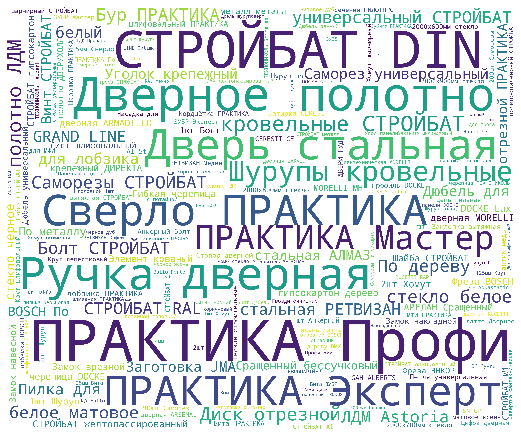

In [235]:
def str_corpus(corpus):
    str_corpus = ''
    for i in corpus:
        str_corpus += ' ' + i
    str_corpus = str_corpus.strip()
    return str_corpus
# Получение списка всех слов в корпусе
def get_corpus(data):
    corpus = []
    for phrase in data:
        for word in phrase.split():
            corpus.append(word)
    return corpus
# Получение облака слов
def get_wordCloud(corpus):
    wordCloud = WordCloud(background_color='white',width=3000,height=2500,max_words=200,random_state=42).generate(str_corpus(corpus))
    return wordCloud

corpus = get_corpus(df_res['Название'].values)
procWordCloud = get_wordCloud(corpus)

fig = plt.figure(figsize=(20, 8))
plt.subplot(1, 2, 1)
plt.imshow(procWordCloud)
plt.axis('off')
plt.subplot(1, 2, 1)

In [236]:
prep_text = [remove_multiple_spaces(remove_numbers(remove_punctuation(text.lower()))) for text in tqdm(df_res['Название'])]


  0%|          | 0/8663 [00:00<?, ?it/s]

In [237]:
len(prep_text)
prep_text[1]

'аэратор технониколь ктв'

In [238]:
df_res['text_prep'] = prep_text
df_res.head(1)

,Название,Артикул,Категория,Цена без карты,Цена с картой,text_prep
0,Проходка BORGE Кровельная D6-50мм прямая №1,17162301,"Главная,Каталог,Строительные материалы,Кровля,...",329.33 ₽,312.86 ₽,проходка borge кровельная d мм прямая №


In [239]:
df_res.shape

(8663, 6)

In [240]:
df_res.head()

,Название,Артикул,Категория,Цена без карты,Цена с картой,text_prep
0,Проходка BORGE Кровельная D6-50мм прямая №1,17162301,"Главная,Каталог,Строительные материалы,Кровля,...",329.33 ₽,312.86 ₽,проходка borge кровельная d мм прямая №
1,Аэратор ТЕХНОНИКОЛЬ КТВ,17575401,"Главная,Каталог,Строительные материалы,Кровля,...",1 529.00 ₽,1 452.55 ₽,аэратор технониколь ктв
2,Аэратор ТЕХНОНИКОЛЬ Pilot скатный,17575301,"Главная,Каталог,Строительные материалы,Кровля,...",3 008.00 ₽,2 857.60 ₽,аэратор технониколь pilot скатный
3,Проходной элемент ТЕХНОНИКОЛЬ Shinglas,17575701,"Главная,Каталог,Строительные материалы,Кровля,...",1 172.00 ₽,1 113.40 ₽,проходной элемент технониколь shinglas
4,Вентиль ТЕХНОНИКОЛЬ Skat кровельный,17575501,"Главная,Каталог,Строительные материалы,Кровля,...",2 396.00 ₽,2 276.20 ₽,вентиль технониколь skat кровельный


In [241]:
from nltk.stem.snowball import SnowballStemmer 
stemmer = SnowballStemmer("russian")

In [242]:
russian_stopwords = stopwords.words("russian")
russian_stopwords.extend(['…', '«', '»', '...', 'т.д.', 'т', 'д','Главная','Каталог'])

In [243]:
import nltk
nltk.download('punkt')
from nltk import word_tokenize
text = df_res['text_prep'][0]
word_tokenize(text)

[nltk_data] Downloading package punkt to /home/mugichu/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


['проходка', 'borge', 'кровельная', 'd', 'мм', 'прямая', '№']

In [244]:
from nltk import word_tokenize

stemmed_texts_list = []
for text in tqdm(df_res['text_prep']):
    tokens = word_tokenize(text)    
    stemmed_tokens = [stemmer.stem(token) for token in tokens if token not in russian_stopwords]
    text = " ".join(stemmed_tokens)
    stemmed_texts_list.append(text)

df_res['text_stem'] = stemmed_texts_list

  0%|          | 0/8663 [00:00<?, ?it/s]

In [245]:
from nltk import word_tokenize

sw_texts_list = []
for text in tqdm(df_res['text_prep']):
    tokens = word_tokenize(text)    
    tokens = [token for token in tokens if token not in russian_stopwords and token != ' ']
    text = " ".join(tokens)
    sw_texts_list.append(text)

df_res['text_sw'] = sw_texts_list

  0%|          | 0/8663 [00:00<?, ?it/s]

In [246]:
def remove_stop_words(text):
    tokens = word_tokenize(text) 
    tokens = [token for token in tokens if token not in russian_stopwords and token != ' ']
    return " ".join(tokens)

In [247]:
df_res['text_sw'][0]

'проходка borge кровельная d мм прямая №'

In [248]:
df_res.to_csv('sp_stemmed.csv')

In [249]:
df_res['text_stem'][0]

'проходк borge кровельн d мм прям №'

In [250]:
lemm_texts_list = []
for text in tqdm(df_res['text_sw']):
    #print(text)
    try:
        text_lem = mystem.lemmatize(text)
        tokens = [token for token in text_lem if token != ' ' and token not in russian_stopwords]
        text = " ".join(tokens)
        lemm_texts_list.append(text)
    except Exception as e:
        print(e)
    
df_res['text_lemm'] = lemm_texts_list

  0%|          | 0/8663 [00:00<?, ?it/s]

In [251]:
def lemmatize_text(text):
    text_lem = mystem.lemmatize(text)
    tokens = [token for token in text_lem if token != ' ']
    return " ".join(tokens)

In [252]:
df_res.to_csv('lemm.csv')

In [253]:
df_res = pd.read_csv('lemm.csv', encoding = 'utf-8')

In [254]:
df_res.head()

,Unnamed: 0,Название,Артикул,Категория,Цена без карты,Цена с картой,text_prep,text_stem,text_sw,text_lemm
0,0,Проходка BORGE Кровельная D6-50мм прямая №1,17162301,"Главная,Каталог,Строительные материалы,Кровля,...",329.33 ₽,312.86 ₽,проходка borge кровельная d мм прямая №,проходк borge кровельн d мм прям №,проходка borge кровельная d мм прямая №,проходка borge кровельный d мм прямой № \n
1,1,Аэратор ТЕХНОНИКОЛЬ КТВ,17575401,"Главная,Каталог,Строительные материалы,Кровля,...",1 529.00 ₽,1 452.55 ₽,аэратор технониколь ктв,аэратор техноникол ктв,аэратор технониколь ктв,аэратор технониколь ктв \n
2,2,Аэратор ТЕХНОНИКОЛЬ Pilot скатный,17575301,"Главная,Каталог,Строительные материалы,Кровля,...",3 008.00 ₽,2 857.60 ₽,аэратор технониколь pilot скатный,аэратор техноникол pilot скатн,аэратор технониколь pilot скатный,аэратор технониколь pilot скатный \n
3,3,Проходной элемент ТЕХНОНИКОЛЬ Shinglas,17575701,"Главная,Каталог,Строительные материалы,Кровля,...",1 172.00 ₽,1 113.40 ₽,проходной элемент технониколь shinglas,проходн элемент техноникол shinglas,проходной элемент технониколь shinglas,проходной элемент технониколь shinglas \n
4,4,Вентиль ТЕХНОНИКОЛЬ Skat кровельный,17575501,"Главная,Каталог,Строительные материалы,Кровля,...",2 396.00 ₽,2 276.20 ₽,вентиль технониколь skat кровельный,вентил техноникол skat кровельн,вентиль технониколь skat кровельный,вентиль технониколь skat кровельный \n


In [255]:
names = df_res['text_lemm']
type(names)

pandas.core.series.Series

<ipython-input-256-0a9cb79cad36>:8: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
  plt.subplot(1, 2, 1)


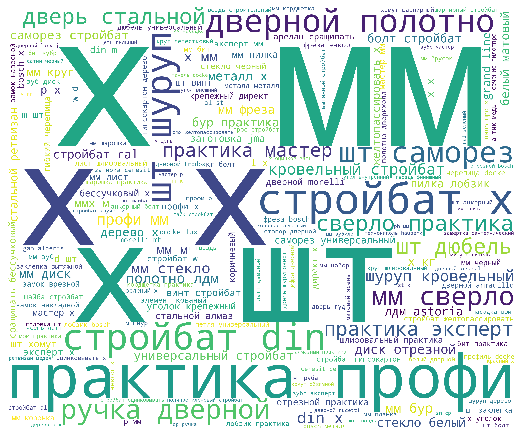

In [256]:
corpus = get_corpus(df_res['text_lemm'].values)
procWordCloud = get_wordCloud(corpus)

fig = plt.figure(figsize=(20, 8))
plt.subplot(1, 2, 1)
plt.imshow(procWordCloud)
plt.axis('off')
plt.subplot(1, 2, 1)

In [257]:
from nltk.stem.snowball import SnowballStemmer
stemmer = SnowballStemmer("russian")

def token_and_stem(text):
    tokens = [word for sent in nltk.sent_tokenize(text) for word in nltk.word_tokenize(sent)]
    filtered_tokens = []
    for token in tokens:
        if re.search('[а-яА-Я]', token):
            filtered_tokens.append(token)
    stems = [stemmer.stem(t) for t in filtered_tokens]
    return stems

In [258]:
stopwords = nltk.corpus.stopwords.words('russian')
#можно расширить список стоп-слов
stopwords.extend(['что', 'это', 'так', 'вот', 'быть', 'как', 'в', 'к', 'на', 'Главная', 'Каталог','\n'])

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

n_featur=200000
tfidf_vectorizer = TfidfVectorizer(max_df=0.8, max_features=10000,
                                 min_df=0.01, stop_words=stopwords,
                                 use_idf=True, tokenizer=token_and_stem, ngram_range=(1,3))

In [259]:
%%time
tfidf_matrix = tfidf_vectorizer.fit_transform(names)

/usr/local/lib/python3.8/dist-packages/sklearn/feature_extraction/text.py:383: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['бол', 'больш', 'будт', 'быт', 'вед', 'впроч', 'всег', 'всегд', 'главн', 'даж', 'друг', 'е', 'ег', 'ем', 'есл', 'ест', 'ещ', 'зач', 'зде', 'ил', 'иногд', 'каталог', 'когд', 'конечн', 'куд', 'лучш', 'межд', 'мен', 'мног', 'мо', 'можн', 'нег', 'нельз', 'нибуд', 'никогд', 'нич', 'опя', 'посл', 'пот', 'почт', 'разв', 'сво', 'себ', 'совс', 'теб', 'тепер', 'тог', 'тогд', 'тож', 'тольк', 'хорош', 'хот', 'чег', 'чут', 'эт'] not in stop_words.
  warnings.warn('Your stop_words may be inconsistent with '


CPU times: user 2.65 s, sys: 0 ns, total: 2.65 s
Wall time: 2.65 s


In [260]:
type(tfidf_matrix)
tfidf_matrix

<8663x141 sparse matrix of type '<class 'numpy.float64'>'
	with 39820 stored elements in Compressed Sparse Row format>

In [261]:
print(tfidf_matrix.shape)

(8663, 141)


In [262]:
tfidf_matrix[:10]

<10x141 sparse matrix of type '<class 'numpy.float64'>'
	with 15 stored elements in Compressed Sparse Row format>

In [329]:
num_clusters = 800

# Метод к-средних - KMeans
from sklearn.cluster import KMeans
km = KMeans(n_clusters=num_clusters)

In [330]:
%%time
km.fit(tfidf_matrix)

CPU times: user 1min 12s, sys: 249 ms, total: 1min 12s
Wall time: 14 s


KMeans(n_clusters=800)

In [331]:
%%time
idx = km.fit(tfidf_matrix)
clusters = km.labels_.tolist()

#print(clusters)
#print (km.labels_)

CPU times: user 1min 19s, sys: 302 ms, total: 1min 19s
Wall time: 14.8 s


In [332]:
len(km.labels_)
clusters[:10]

[222, 66, 66, 66, 254, 254, 675, 66, 66, 254]

In [333]:
clusterkm = km.labels_.tolist()
frame = pd.DataFrame(names)

#k-means
out = { 'names': names, 'cluster': clusterkm, 'topic': df_res['Категория'] }
frame1 = pd.DataFrame(out, columns = ['names', 'cluster', 'topic'])

In [342]:
frame1

,names,cluster,topic
0,проходка borge кровельный d мм прямой № \n,222,"Главная,Каталог,Строительные материалы,Кровля,..."
1,аэратор технониколь ктв \n,66,"Главная,Каталог,Строительные материалы,Кровля,..."
2,аэратор технониколь pilot скатный \n,66,"Главная,Каталог,Строительные материалы,Кровля,..."
3,проходной элемент технониколь shinglas \n,66,"Главная,Каталог,Строительные материалы,Кровля,..."
4,вентиль технониколь skat кровельный \n,254,"Главная,Каталог,Строительные материалы,Кровля,..."
...,...,...,...
8658,ключ разводной kraftool \n,1,"Главная,Каталог,Инструменты и крепёж,Столярно-..."
8659,ключ кобальт \n,1,"Главная,Каталог,Инструменты и крепёж,Столярно-..."
8660,ключ кобальт \n,1,"Главная,Каталог,Инструменты и крепёж,Столярно-..."
8661,ключ кобальт \n,1,"Главная,Каталог,Инструменты и крепёж,Столярно-..."


In [335]:
fp = frame1[frame1.topic.eq('Главная,Каталог,Строительные материалы,Строительство из ГКЛ,Комплектующие для гипсокартона') & frame1.cluster.eq(2)]
print(len(fp))

0


In [336]:
# MiniBatchKMeans
from sklearn.cluster import MiniBatchKMeans

mbk  = MiniBatchKMeans(init='random', n_clusters=num_clusters) #(init='k-means++', ‘random’ or an ndarray)
mbk.fit_transform(tfidf_matrix)
%time mbk.fit(tfidf_matrix)
miniclusters = mbk.labels_.tolist()
print (mbk.labels_)

CPU times: user 1.59 s, sys: 3.97 ms, total: 1.6 s
Wall time: 208 ms
[298 590 590 ...   8   8   8]


In [337]:
print(topic)
print(num_clusters)

Главная,Каталог,Инструменты и крепёж,Столярно-слесарный инструмент,Ключи разводные
800


In [338]:
for topic in topics:
    print(topic, end = ' \t\t ')
    for cluster in range(num_clusters):
        print(cluster, ' : ', len(frame1[ frame1.topic.eq(topic) &  frame1.cluster.eq(cluster) ]), end = ' ')
    print()

Главная,Каталог,Строительные материалы,Кровля,Вентиляция для кровли 		 0  :  0 1  :  4 2  :  0 3  :  0 4  :  0 5  :  0 6  :  0 7  :  0 8  :  0 9  :  0 10  :  0 11  :  0 12  :  0 13  :  0 14  :  0 15  :  0 16  :  0 17  :  0 18  :  0 19  :  0 20  :  0 21  :  0 22  :  0 23  :  0 24  :  0 25  :  0 26  :  0 27  :  0 28  :  0 29  :  0 30  :  0 31  :  0 32  :  0 33  :  0 34  :  0 35  :  0 36  :  0 37  :  0 38  :  0 39  :  0 40  :  0 41  :  0 42  :  0 43  :  0 44  :  0 45  :  0 46  :  0 47  :  0 48  :  0 49  :  0 50  :  0 51  :  0 52  :  0 53  :  0 54  :  0 55  :  0 56  :  0 57  :  0 58  :  0 59  :  0 60  :  0 61  :  0 62  :  0 63  :  0 64  :  0 65  :  0 66  :  7 67  :  0 68  :  0 69  :  0 70  :  0 71  :  0 72  :  0 73  :  0 74  :  0 75  :  0 76  :  0 77  :  0 78  :  0 79  :  0 80  :  0 81  :  0 82  :  0 83  :  0 84  :  0 85  :  0 86  :  0 87  :  0 88  :  0 89  :  0 90  :  0 91  :  0 92  :  0 93  :  0 94  :  0 95  :  0 96  :  0 97  :  0 98  :  0 99  :  0 100  :  0 101  :  0 102  :  0 103  :  0

Главная,Каталог,Строительные материалы,Кровля,Кровельные мастики 		 0  :  0 1  :  0 2  :  0 3  :  0 4  :  0 5  :  0 6  :  0 7  :  0 8  :  0 9  :  0 10  :  0 11  :  0 12  :  0 13  :  0 14  :  0 15  :  0 16  :  0 17  :  0 18  :  0 19  :  0 20  :  0 21  :  0 22  :  0 23  :  0 24  :  0 25  :  0 26  :  0 27  :  0 28  :  0 29  :  0 30  :  0 31  :  0 32  :  0 33  :  0 34  :  0 35  :  0 36  :  0 37  :  0 38  :  0 39  :  0 40  :  0 41  :  0 42  :  0 43  :  0 44  :  0 45  :  0 46  :  0 47  :  0 48  :  0 49  :  0 50  :  0 51  :  0 52  :  0 53  :  0 54  :  0 55  :  0 56  :  0 57  :  0 58  :  0 59  :  0 60  :  0 61  :  0 62  :  0 63  :  0 64  :  0 65  :  0 66  :  1 67  :  0 68  :  0 69  :  0 70  :  3 71  :  0 72  :  0 73  :  0 74  :  0 75  :  0 76  :  0 77  :  0 78  :  0 79  :  0 80  :  0 81  :  0 82  :  0 83  :  0 84  :  0 85  :  0 86  :  0 87  :  0 88  :  0 89  :  0 90  :  0 91  :  0 92  :  0 93  :  0 94  :  0 95  :  0 96  :  0 97  :  0 98  :  0 99  :  0 100  :  0 101  :  0 102  :  0 103  :  0 10

Главная,Каталог,Строительные материалы,Кровля,Металлочерепица 		 0  :  0 1  :  0 2  :  0 3  :  0 4  :  0 5  :  0 6  :  0 7  :  0 8  :  0 9  :  0 10  :  0 11  :  1 12  :  0 13  :  0 14  :  0 15  :  4 16  :  0 17  :  0 18  :  0 19  :  0 20  :  0 21  :  0 22  :  0 23  :  0 24  :  0 25  :  0 26  :  0 27  :  0 28  :  0 29  :  0 30  :  0 31  :  0 32  :  0 33  :  0 34  :  0 35  :  0 36  :  0 37  :  0 38  :  4 39  :  1 40  :  0 41  :  0 42  :  0 43  :  0 44  :  0 45  :  0 46  :  0 47  :  0 48  :  0 49  :  0 50  :  0 51  :  0 52  :  0 53  :  0 54  :  0 55  :  0 56  :  4 57  :  0 58  :  0 59  :  0 60  :  0 61  :  0 62  :  0 63  :  0 64  :  0 65  :  0 66  :  0 67  :  0 68  :  0 69  :  0 70  :  0 71  :  0 72  :  0 73  :  0 74  :  0 75  :  0 76  :  0 77  :  0 78  :  0 79  :  0 80  :  0 81  :  0 82  :  0 83  :  4 84  :  0 85  :  0 86  :  0 87  :  0 88  :  0 89  :  0 90  :  0 91  :  0 92  :  0 93  :  0 94  :  0 95  :  0 96  :  0 97  :  0 98  :  0 99  :  0 100  :  0 101  :  0 102  :  0 103  :  0 104  

Главная,Каталог,Строительные материалы,Кровля,Профнастил 		 0  :  0 1  :  0 2  :  0 3  :  0 4  :  0 5  :  0 6  :  0 7  :  0 8  :  0 9  :  0 10  :  0 11  :  3 12  :  0 13  :  0 14  :  0 15  :  0 16  :  0 17  :  0 18  :  0 19  :  0 20  :  0 21  :  0 22  :  0 23  :  0 24  :  0 25  :  0 26  :  0 27  :  0 28  :  0 29  :  0 30  :  0 31  :  0 32  :  0 33  :  0 34  :  0 35  :  0 36  :  0 37  :  0 38  :  0 39  :  2 40  :  0 41  :  0 42  :  0 43  :  0 44  :  0 45  :  0 46  :  0 47  :  0 48  :  0 49  :  0 50  :  0 51  :  0 52  :  0 53  :  0 54  :  0 55  :  0 56  :  0 57  :  0 58  :  0 59  :  0 60  :  0 61  :  0 62  :  0 63  :  0 64  :  0 65  :  0 66  :  0 67  :  0 68  :  0 69  :  0 70  :  0 71  :  0 72  :  0 73  :  0 74  :  0 75  :  0 76  :  0 77  :  0 78  :  0 79  :  0 80  :  0 81  :  0 82  :  0 83  :  0 84  :  0 85  :  0 86  :  0 87  :  0 88  :  0 89  :  0 90  :  0 91  :  0 92  :  0 93  :  0 94  :  0 95  :  0 96  :  0 97  :  0 98  :  0 99  :  0 100  :  0 101  :  0 102  :  0 103  :  0 104  :  0 

Главная,Каталог,Строительные материалы,Строительные сухие смеси и клеи,Затирки 		 0  :  0 1  :  53 2  :  0 3  :  0 4  :  0 5  :  0 6  :  0 7  :  0 8  :  0 9  :  0 10  :  12 11  :  0 12  :  0 13  :  0 14  :  0 15  :  0 16  :  0 17  :  0 18  :  0 19  :  0 20  :  0 21  :  0 22  :  0 23  :  0 24  :  0 25  :  0 26  :  0 27  :  0 28  :  0 29  :  0 30  :  0 31  :  0 32  :  0 33  :  0 34  :  0 35  :  0 36  :  0 37  :  0 38  :  0 39  :  0 40  :  0 41  :  0 42  :  1 43  :  0 44  :  0 45  :  0 46  :  0 47  :  0 48  :  0 49  :  0 50  :  5 51  :  0 52  :  0 53  :  0 54  :  0 55  :  0 56  :  0 57  :  0 58  :  0 59  :  0 60  :  0 61  :  0 62  :  0 63  :  0 64  :  0 65  :  0 66  :  0 67  :  0 68  :  0 69  :  0 70  :  0 71  :  0 72  :  0 73  :  0 74  :  0 75  :  0 76  :  0 77  :  0 78  :  0 79  :  0 80  :  0 81  :  0 82  :  0 83  :  0 84  :  0 85  :  0 86  :  0 87  :  0 88  :  0 89  :  0 90  :  0 91  :  0 92  :  0 93  :  0 94  :  0 95  :  0 96  :  0 97  :  0 98  :  0 99  :  0 100  :  0 101  :  0 102  :

...

Главная,Каталог,Инструменты и крепёж,Расходные материалы для инструмента,Расходные материалы для сварки 		 0  :  0 1  :  35 2  :  0 3  :  0 4  :  0 5  :  0 6  :  0 7  :  0 8  :  0 9  :  0 10  :  0 11  :  0 12  :  0 13  :  0 14  :  0 15  :  4 16  :  0 17  :  0 18  :  0 19  :  0 20  :  0 21  :  0 22  :  0 23  :  0 24  :  0 25  :  0 26  :  0 27  :  0 28  :  0 29  :  0 30  :  0 31  :  0 32  :  0 33  :  0 34  :  0 35  :  0 36  :  0 37  :  0 38  :  0 39  :  0 40  :  0 41  :  0 42  :  0 43  :  0 44  :  6 45  :  0 46  :  0 47  :  0 48  :  0 49  :  0 50  :  0 51  :  0 52  :  0 53  :  0 54  :  0 55  :  0 56  :  0 57  :  1 58  :  0 59  :  0 60  :  0 61  :  0 62  :  0 63  :  0 64  :  0 65  :  0 66  :  0 67  :  0 68  :  0 69  :  0 70  :  0 71  :  0 72  :  0 73  :  0 74  :  0 75  :  0 76  :  0 77  :  0 78  :  0 79  :  0 80  :  0 81  :  0 82  :  0 83  :  0 84  :  0 85  :  0 86  :  0 87  :  0 88  :  0 89  :  0 90  :  0 91  :  0 92  :  0 93  :  0 94  :  0 95  :  0 96  :  0 97  :  0 98  :  0 99  :  0 10

Главная,Каталог,Инструменты и крепёж,Расходные материалы для инструмента,Свёрла, патроны 		 0  :  0 1  :  2 2  :  0 3  :  0 4  :  0 5  :  0 6  :  0 7  :  0 8  :  0 9  :  0 10  :  0 11  :  0 12  :  0 13  :  0 14  :  0 15  :  3 16  :  0 17  :  0 18  :  0 19  :  0 20  :  0 21  :  0 22  :  0 23  :  0 24  :  167 25  :  0 26  :  0 27  :  0 28  :  0 29  :  0 30  :  0 31  :  0 32  :  0 33  :  0 34  :  0 35  :  0 36  :  0 37  :  0 38  :  0 39  :  0 40  :  0 41  :  0 42  :  0 43  :  0 44  :  0 45  :  0 46  :  26 47  :  0 48  :  0 49  :  0 50  :  0 51  :  0 52  :  0 53  :  0 54  :  0 55  :  0 56  :  0 57  :  1 58  :  0 59  :  0 60  :  0 61  :  0 62  :  0 63  :  0 64  :  0 65  :  0 66  :  0 67  :  0 68  :  0 69  :  0 70  :  0 71  :  0 72  :  0 73  :  0 74  :  0 75  :  0 76  :  0 77  :  0 78  :  0 79  :  0 80  :  0 81  :  0 82  :  0 83  :  0 84  :  0 85  :  0 86  :  0 87  :  8 88  :  0 89  :  0 90  :  0 91  :  0 92  :  43 93  :  0 94  :  0 95  :  1 96  :  0 97  :  0 98  :  0 99  :  0 100  :  0 101 

Главная,Каталог,Инструменты и крепёж,Расходные материалы для инструмента,Шарошки 		 0  :  0 1  :  0 2  :  0 3  :  0 4  :  0 5  :  2 6  :  0 7  :  0 8  :  0 9  :  0 10  :  0 11  :  0 12  :  0 13  :  0 14  :  0 15  :  0 16  :  0 17  :  0 18  :  0 19  :  0 20  :  0 21  :  0 22  :  0 23  :  0 24  :  0 25  :  0 26  :  0 27  :  0 28  :  0 29  :  0 30  :  0 31  :  0 32  :  0 33  :  0 34  :  0 35  :  0 36  :  0 37  :  0 38  :  0 39  :  4 40  :  0 41  :  0 42  :  0 43  :  0 44  :  0 45  :  0 46  :  0 47  :  0 48  :  0 49  :  0 50  :  0 51  :  0 52  :  0 53  :  0 54  :  0 55  :  0 56  :  0 57  :  3 58  :  0 59  :  0 60  :  0 61  :  0 62  :  0 63  :  0 64  :  0 65  :  10 66  :  0 67  :  0 68  :  0 69  :  0 70  :  0 71  :  0 72  :  0 73  :  13 74  :  2 75  :  0 76  :  0 77  :  0 78  :  0 79  :  0 80  :  0 81  :  0 82  :  0 83  :  0 84  :  0 85  :  0 86  :  0 87  :  0 88  :  0 89  :  0 90  :  0 91  :  0 92  :  0 93  :  0 94  :  0 95  :  0 96  :  0 97  :  0 98  :  0 99  :  0 100  :  0 101  :  0 102 

Главная,Каталог,Инструменты и крепёж,Столярно-слесарный инструмент,Заклёпочники 		 0  :  0 1  :  9 2  :  0 3  :  0 4  :  0 5  :  0 6  :  0 7  :  0 8  :  0 9  :  0 10  :  0 11  :  0 12  :  0 13  :  0 14  :  0 15  :  0 16  :  0 17  :  0 18  :  0 19  :  0 20  :  0 21  :  0 22  :  0 23  :  0 24  :  0 25  :  0 26  :  0 27  :  0 28  :  0 29  :  0 30  :  0 31  :  0 32  :  0 33  :  0 34  :  0 35  :  0 36  :  0 37  :  0 38  :  0 39  :  0 40  :  0 41  :  0 42  :  0 43  :  0 44  :  0 45  :  0 46  :  0 47  :  0 48  :  0 49  :  0 50  :  0 51  :  0 52  :  0 53  :  0 54  :  0 55  :  0 56  :  0 57  :  0 58  :  0 59  :  0 60  :  0 61  :  0 62  :  0 63  :  0 64  :  0 65  :  0 66  :  0 67  :  0 68  :  0 69  :  0 70  :  0 71  :  0 72  :  0 73  :  0 74  :  0 75  :  0 76  :  0 77  :  0 78  :  0 79  :  0 80  :  0 81  :  0 82  :  0 83  :  0 84  :  0 85  :  0 86  :  0 87  :  0 88  :  0 89  :  0 90  :  0 91  :  0 92  :  0 93  :  0 94  :  0 95  :  0 96  :  0 97  :  0 98  :  0 99  :  0 100  :  0 101  :  0 102  : 

Главная,Каталог,Инструменты и крепёж,Столярно-слесарный инструмент,Ключи разводные 		 0  :  0 1  :  11 2  :  0 3  :  0 4  :  0 5  :  0 6  :  0 7  :  0 8  :  0 9  :  0 10  :  0 11  :  0 12  :  0 13  :  0 14  :  0 15  :  0 16  :  0 17  :  0 18  :  0 19  :  0 20  :  0 21  :  0 22  :  0 23  :  0 24  :  0 25  :  0 26  :  0 27  :  0 28  :  0 29  :  0 30  :  0 31  :  0 32  :  0 33  :  0 34  :  0 35  :  0 36  :  0 37  :  0 38  :  0 39  :  0 40  :  0 41  :  0 42  :  0 43  :  0 44  :  0 45  :  0 46  :  0 47  :  0 48  :  0 49  :  0 50  :  0 51  :  0 52  :  0 53  :  0 54  :  0 55  :  0 56  :  0 57  :  0 58  :  0 59  :  0 60  :  0 61  :  0 62  :  0 63  :  0 64  :  0 65  :  0 66  :  0 67  :  0 68  :  0 69  :  0 70  :  0 71  :  0 72  :  0 73  :  0 74  :  0 75  :  0 76  :  0 77  :  0 78  :  0 79  :  0 80  :  0 81  :  0 82  :  0 83  :  0 84  :  0 85  :  0 86  :  0 87  :  0 88  :  0 89  :  0 90  :  0 91  :  0 92  :  0 93  :  0 94  :  0 95  :  0 96  :  0 97  :  0 98  :  0 99  :  0 100  :  0 101  :  0 102

In [354]:
test_text = 'клей'

In [355]:
text_vec = tfidf_vectorizer.transform([test_text])
pd.DataFrame.sparse.from_spmatrix(text_vec)

,0,1,2,3,4,5,6,7,8,9,...,131,132,133,134,135,136,137,138,139,140
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [356]:
km.predict(text_vec)

array([1], dtype=int32)

In [306]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import linear_kernel
from sklearn.metrics.pairwise import cosine_similarity
 
# зададим массив текстов
some_texts = [
   'текст номер один',
   'текст номер два',
   'текст следующий под номером три',
]
df = pd.DataFrame({'texts': some_texts})

In [197]:
find_nearest_to = "документ номер два"

In [198]:
# формирование весов tf-idf
tfidf = TfidfVectorizer()
mx_tf = tfidf.fit_transform(some_texts)
new_entry = tfidf.transform([find_nearest_to])

In [199]:
type(mx_tf)

scipy.sparse.csr.csr_matrix

In [200]:
sdf = pd.DataFrame.sparse.from_spmatrix(mx_tf)
sdf

,0,1,2,3,4,5,6,7
0,0.000000,0.547832,0.000000,0.720333,0.000000,0.000000,0.425441,0.000000
1,0.720333,0.547832,0.000000,0.000000,0.000000,0.000000,0.425441,0.000000
2,0.000000,0.000000,0.479528,0.000000,0.479528,0.479528,0.283217,0.479528


In [201]:
cosine_similarity(mx_tf)

array([[1.        , 0.48111972, 0.12049196],
       [0.48111972, 1.        , 0.12049196],
       [0.12049196, 0.12049196, 1.        ]])

In [202]:
new_entry = tfidf.transform([find_nearest_to])
pd.DataFrame.sparse.from_spmatrix(new_entry)

,0,1,2,3,4,5,6,7
0,0.795961,0.605349,0.0,0.0,0.0,0.0,0.0,0.0


In [203]:
cosine_similarities = cosine_similarity(new_entry, mx_tf).flatten()
cosine_similarities

array([0.33162938, 0.90498638, 0.        ])

In [204]:
# запишем все попарные результаты сравнений
df['cos_similarities'] = cosine_similarities
# и отсортируем по убыванию (т.к. cos(0)=1)
df = df.sort_values(by=['cos_similarities'], ascending=[0])
df

,texts,cos_similarities
1,текст номер два,0.904986
0,текст номер один,0.331629
2,текст следующий под номером три,0.000000
